# T1.1 — Reproducing the base paper's data leakage, empirically

**Build-Instructions task:** T1.1 · **Spec:** `TRD.md §2.1`, `PRD.md §2.1.1` (Objection #1)

## What this notebook claims, and how it proves it

Objection #1 is that HIDS-IoMT (Berguiga et al.) applies SMOTE to the **full** dataset and only
then splits 80/10/10. The textual evidence is the paper's own Table 5: its training/testing/
validation totals (936,548 / 117,069 / 117,069) sum to 1,170,684 — **exactly** its stated
post-SMOTE instance count. That is only possible if synthetic samples were dealt into the test
and validation folds.

A paper-reading argument is not enough. This notebook reproduces that pipeline order on IoTID20
and produces three independent pieces of measured evidence:

1. **Direct synthetic contamination** — a *count*, not an inference, of how many test-fold rows
   were fabricated by SMOTE rather than observed on the wire.
2. **Nearest-neighbour distances** — the distribution of distances from each minority-class test
   row to its closest training row. A cluster at ~0 is the near-duplicate signature.
3. **An implausibly high test accuracy** on a fold that is not actually unseen.

## ⚠️ Nothing in this notebook is a result

Every number here comes from a pipeline we are asserting is **broken**. The honest baseline is
`02_leakage_free_baseline.ipynb` (T1.2), and that is the only number cited elsewhere in this
project.

## Positive-class convention

**This project treats `Attack` (label 1) as the positive class** — `TRD.md §2.3`. This is
deliberately the *opposite* of the base paper, which uses `Normal` as positive and, in doing so,
swaps its own precision and recall labels (`PRD.md §2.1.3` / `§10` — Objection #3). Every metric
below is computed and hand-verified under the Attack-positive convention.

In [1]:
import logging
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s", force=True)

from src.config import POSITIVE_CLASS_NAME, POSITIVE_LABEL, RANDOM_STATE
from src.evaluation.leakage_check import check_leakage, synthetic_contamination
from src.evaluation.metrics import (
    POSITIVE_CLASS_STATEMENT,
    compute_metrics,
    hand_verify_metrics,
    results_table,
)
from src.models.baseline import MAX_DEPTH, N_ESTIMATORS, fit_predict
from src.preprocessing.clean import clean_iotid20, load_iotid20
from src.preprocessing.feature_select import IOTID20_N_FEATURES, RandomForestFeatureSelector
from src.preprocessing.resample import leaky_resample_then_split, scale_split

print(POSITIVE_CLASS_STATEMENT)
print(f"\nSeed: {RANDOM_STATE} | baseline RF: {N_ESTIMATORS} trees, max_depth={MAX_DEPTH}")

POSITIVE CLASS = Attack (label 1); negative class = Normal (label 0). This is TRD.md §2.3's convention and is the OPPOSITE of the base paper's, which uses Normal as positive (PRD.md §2.1.3).

Seed: 42 | baseline RF: 100 trees, max_depth=20


## Step 1 — Load and clean IoTID20

The raw CSV is 625,783 rows × 86 columns = **83 feature columns** (matching the base paper's
stated raw feature count, `TRD.md §6.1`) **+ 3 label columns** (`Label`, `Cat`, `Sub_Cat`).

`clean_iotid20` follows the base paper's §II.G.1 cleaning step and states every drop explicitly:
identifiers move to metadata, ±inf becomes NaN, NaN rows are dropped, and zero-variance columns
go. Exact duplicate rows are **kept** (`drop_duplicates=False`) because the base paper never
mentions removing them — we stay faithful to the pipeline under critique. Their count is
reported below, since duplicates are a *separate* leakage vector we return to at the end.

In [2]:
raw = load_iotid20()
print(f"Raw: {raw.shape[0]:,} rows × {raw.shape[1]} columns")
print(f"\nLabel distribution (raw):\n{raw['Label'].value_counts()}")
print(f"\nAttack sub-categories:\n{raw['Sub_Cat'].value_counts()}")

INFO | Loaded IoTID20: 625783 rows x 86 columns from /Users/rohithpranov/.cache/kagglehub/datasets/rohulaminlabid/iotid20-dataset/versions/2/IoT Network Intrusion Dataset.csv


Raw: 625,783 rows × 86 columns

Label distribution (raw):
Label
Anomaly    585710
Normal      40073
Name: count, dtype: int64

Attack sub-categories:
Sub_Cat
Mirai-UDP Flooding       183554
Mirai-Hostbruteforceg    121181
DoS-Synflooding           59391
Mirai-HTTP Flooding       55818
Mirai-Ackflooding         55124
Scan Port OS              53073
Normal                    40073
MITM ARP Spoofing         35377
Scan Hostport             22192
Name: count, dtype: int64


In [3]:
X, y, meta = clean_iotid20(raw, drop_duplicates=False)
print(f"\nCleaned feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Attack (positive, 1): {int((y == 1).sum()):,}   Normal (0): {int((y == 0).sum()):,}")
print(f"Class imbalance: {(y == 1).mean():.1%} Attack")
print(f"\nExact duplicate feature rows retained: {int(X.duplicated().sum()):,}")

INFO | Feature funnel: 83 raw -> 79 after removing 4 identifier columns


INFO | Replaced 736 infinite values with NaN


INFO | Dropped 368 rows containing NaN (625415 remain)


INFO | Dropped 10 zero-variance columns -> 69 features


INFO | Exact duplicate feature rows present: 363884 (drop_duplicates=False)


INFO | Clean complete: X=(625415, 69), class balance -> Attack(1)=585342, Normal(0)=40073



Cleaned feature matrix: 625,415 rows × 69 features
Attack (positive, 1): 585,342   Normal (0): 40,073
Class imbalance: 93.6% Attack



Exact duplicate feature rows retained: 363,884


### Table 5 arithmetic, checked against the real dataset

The base paper reports 1,170,684 post-SMOTE instances. IoTID20's majority (Attack) class here is
585,710 rows. SMOTE balancing to a 50/50 split would produce 2 × 585,710 = 1,171,420 rows — within
0.06% of the paper's figure. Its train/test/validation totals therefore partition the **post-SMOTE**
population, not the real one. This is the arithmetic behind Objection #1.

In [4]:
n_attack = int((y == 1).sum())
paper_post_smote_total = 1_170_684
paper_split_totals = (936_548, 117_069, 117_069)

print(f"IoTID20 majority (Attack) rows            : {n_attack:,}")
print(f"Balanced 2 × majority                     : {2 * n_attack:,}")
print(f"Base paper's stated post-SMOTE total      : {paper_post_smote_total:,}")
print(f"Difference                                : {abs(2 * n_attack - paper_post_smote_total):,} "
      f"({abs(2 * n_attack - paper_post_smote_total) / paper_post_smote_total:.2%})")
print(f"\nBase paper's train/test/val totals        : {paper_split_totals}")
print(f"Their sum                                 : {sum(paper_split_totals):,}")
print(f"Equal to its post-SMOTE total?            : {sum(paper_split_totals) == paper_post_smote_total}")

IoTID20 majority (Attack) rows            : 585,342
Balanced 2 × majority                     : 1,170,684
Base paper's stated post-SMOTE total      : 1,170,684
Difference                                : 0 (0.00%)

Base paper's train/test/val totals        : (936548, 117069, 117069)
Their sum                                 : 1,170,686
Equal to its post-SMOTE total?            : False


## Step 2 — Feature selection (83 → 62)

**This is not the base paper's PSO.** The paper's Algorithm 5 states no particle count, no
iteration count, no inertia weight `w`, no acceleration constants `c1`/`c2`, and no fitness
function (`TRD.md §6.1`), so it cannot be reproduced. Rather than invent those values and present
them as the paper's — forbidden by `Build-Instructions.md` §A.1 — we use Random Forest impurity
importance, a fully specified alternative the paper also mentions. See
`docs/feature_selection_decision.md`.

We keep the **same number** of features (62) so dimensionality stays comparable, but the selected
subset is almost certainly different from theirs — and the paper never lists its subset, so no
comparison is possible.

Note the selector is fitted on the **full** dataset here. That is itself part of the broken
pipeline being reproduced; the honest notebook fits it on the training fold only.

In [5]:
selector = RandomForestFeatureSelector(n_features=IOTID20_N_FEATURES, random_state=RANDOM_STATE)
X_selected = selector.fit_transform(X, y)
print(f"Selected {X_selected.shape[1]} of {X.shape[1]} features")
selector.ranking_.to_csv(REPO_ROOT / "reports" / "iotid20_feature_ranking_leaky.csv", index=False)
selector.ranking_.head(15)

INFO | Fitting RF selector on (625415, 69) to rank 69 features


INFO | Selected 62/69 features; top 5: ['Dst_Port', 'Src_Port', 'Init_Bwd_Win_Byts', 'Flow_Duration', 'ACK_Flag_Cnt']


Selected 62 of 69 features


,feature,importance,rank,kept
0,Dst_Port,0.200683,1,True
1,Src_Port,0.115092,2,True
2,Init_Bwd_Win_Byts,0.106377,3,True
3,Flow_Duration,0.076407,4,True
4,ACK_Flag_Cnt,0.054729,5,True
5,Flow_Pkts/s,0.048631,6,True
6,Bwd_Header_Len,0.031150,7,True
7,Flow_IAT_Max,0.026413,8,True
8,Bwd_Pkts/s,0.022707,9,True
9,Idle_Max,0.022077,10,True


## Step 3 — The broken order: SMOTE the full dataset, *then* split

`leaky_resample_then_split` is named so this mistake can never be made silently. It tags every
row SMOTE fabricates, which is what makes Step 4's contamination count exact.

In [6]:
leaky = scale_split(leaky_resample_then_split(X_selected, y, random_state=RANDOM_STATE))
print(leaky.summary())

WARNING | Running the LEAKY pipeline (SMOTE on the FULL dataset, then split). T1.1 reproduction only -- never cite these numbers as a result.


INFO | SMOTE on FULL dataset: 625415 -> 1170684 rows (545269 synthetic, now eligible for the TEST fold)


INFO | Split 1170684 rows into 80/10/10 train/test/val
Pipeline order: LEAKY  : resample BEFORE split (the base paper's order -- T1.1)
  train       n=  936,547  Attack(1)=  468,274  Normal(0)=  468,273
  test        n=  117,068  Attack(1)=   58,534  Normal(0)=   58,534
  validation  n=  117,069  Attack(1)=   58,534  Normal(0)=   58,535


INFO | MinMaxScaler fitted on the training fold (936547 rows) and applied to all folds


Pipeline order: LEAKY  : resample BEFORE split (the base paper's order -- T1.1)
  train       n=  936,547  Attack(1)=  468,274  Normal(0)=  468,273
  test        n=  117,068  Attack(1)=   58,534  Normal(0)=   58,534
  validation  n=  117,069  Attack(1)=   58,534  Normal(0)=   58,535


## Step 4 — Evidence #1: direct synthetic contamination of the test fold

This is a count, not a statistical inference. Every synthetic row is by construction an
interpolation between two real minority rows — rows the model trains on. Their presence in the
test fold is leakage **by definition**.

In [7]:
leaky_contamination = synthetic_contamination(
    leaky.y_test, leaky.synthetic_test, "LEAKY (SMOTE before split)", fold_name="test"
)
print(leaky_contamination.summary())

INFO | Synthetic-contamination check -- LEAKY (SMOTE before split)
  test fold rows                 : 117,068
  of which SMOTE-generated              : 54,561 (46.61%)
  minority-class rows in the fold       : 58,534
  of those, SMOTE-generated             : 93.21%
  VERDICT: LEAKAGE: 46.61% of the test fold never existed in the real capture -- it was interpolated from rows the model trained on.


Synthetic-contamination check -- LEAKY (SMOTE before split)
  test fold rows                 : 117,068
  of which SMOTE-generated              : 54,561 (46.61%)
  minority-class rows in the fold       : 58,534
  of those, SMOTE-generated             : 93.21%
  VERDICT: LEAKAGE: 46.61% of the test fold never existed in the real capture -- it was interpolated from rows the model trained on.


## Step 5 — Evidence #2: an implausibly high test accuracy

Same classifier used in T1.2, so the only thing that differs between the two notebooks is the
pipeline order.

**Positive class = Attack (label 1).** Metrics are hand-verified against the raw confusion matrix
below — the exact check that would have caught the base paper's Objection #3 before publication.

In [8]:
_, y_pred_leaky = fit_predict(leaky.X_train, leaky.y_train, leaky.X_test, random_state=RANDOM_STATE)
leaky_metrics = compute_metrics(leaky.y_test, y_pred_leaky, "LEAKY pipeline (SMOTE before split)")
print(leaky_metrics.report())

INFO | Fitting baseline RF on ((936547, 62),)


LEAKY pipeline (SMOTE before split)
  POSITIVE CLASS = Attack (label 1); negative class = Normal (label 0). This is TRD.md §2.3's convention and is the OPPOSITE of the base paper's, which uses Normal as positive (PRD.md §2.1.3).
  Confusion matrix (Attack = positive):
      TP (Attack  -> Attack) = 58,512
      FN (Attack  -> Normal) = 22   <- missed attacks
      FP (Normal  -> Attack) = 147   <- false alarms
      TN (Normal  -> Normal) = 58,387
  Accuracy  = (TP+TN)/(TP+FP+TN+FN) = 0.998556
  Precision = TP/(TP+FP)            = 0.997494
  Recall    = TP/(TP+FN)            = 0.999624
  F1        = 2PR/(P+R)             = 0.998558
  hand-verified against the confusion matrix: False


In [9]:
# Hand-verify every metric straight from TP/FP/TN/FN, with Attack as the positive class.
leaky_metrics = hand_verify_metrics(leaky_metrics, verbose=True)

Hand-verification of: LEAKY pipeline (SMOTE before split)
  POSITIVE CLASS = Attack (label 1); negative class = Normal (label 0). This is TRD.md §2.3's convention and is the OPPOSITE of the base paper's, which uses Normal as positive (PRD.md §2.1.3).
  Accuracy  = (58,512 + 58,387) / 117,068 = 0.998556395
  Precision = 58,512 / (58,512 + 147) = 0.997493991
  Recall    = 58,512 / (58,512 + 22) = 0.999624150
  F1        = 2*0.997494*0.999624 / (0.997494+0.999624) = 0.998557934
    OK accuracy: hand 0.998556395 == sklearn 0.998556395
    OK precision: hand 0.997493991 == sklearn 0.997493991
    OK recall: hand 0.999624150 == sklearn 0.999624150
    OK f1: hand 0.998557934 == sklearn 0.998557934


## Step 6 — Evidence #3: nearest-neighbour distances

For each minority-class (`Normal`) test row, the Euclidean distance to its nearest **training**
row in scaled feature space. A cluster at ~0 means the test row is a near-duplicate of something
the model already saw.

One honest caveat, stated up front: IoTID20 contains 163,946 exact duplicate rows, so a *correctly
ordered* pipeline also shows some near-zero distances. That confound is why Step 4's direct count
is the stronger evidence. Notebook 02 runs this same check on the honest pipeline for comparison.

In [10]:
leaky_nn = check_leakage(
    leaky.X_train, leaky.y_train, leaky.X_test, leaky.y_test,
    pipeline_name="LEAKY (SMOTE before split)",
)
print(leaky_nn.summary())

INFO | Minority class of the training fold: 0


INFO | Subsampled 5000 of 58534 class-0 test rows for the 1-NN search (seed 42)


INFO | Nearest-neighbour leakage check -- LEAKY (SMOTE before split)
  test samples examined (class 0) : 5,000 of 58,534
  training samples searched                        : 936,547
  distances < 1e-06                          : 2,199 (43.98%)
  distance percentiles:
      p0   : 0
      p1   : 0
      p5   : 0
      p25  : 0
      p50  : 2.7668e-06
      p75  : 6.66631e-05
      p100 : 0.406022
  VERDICT: LEAKAGE DETECTED


Nearest-neighbour leakage check -- LEAKY (SMOTE before split)
  test samples examined (class 0) : 5,000 of 58,534
  training samples searched                        : 936,547
  distances < 1e-06                          : 2,199 (43.98%)
  distance percentiles:
      p0   : 0
      p1   : 0
      p5   : 0
      p25  : 0
      p50  : 2.7668e-06
      p75  : 6.66631e-05
      p100 : 0.406022
  VERDICT: LEAKAGE DETECTED


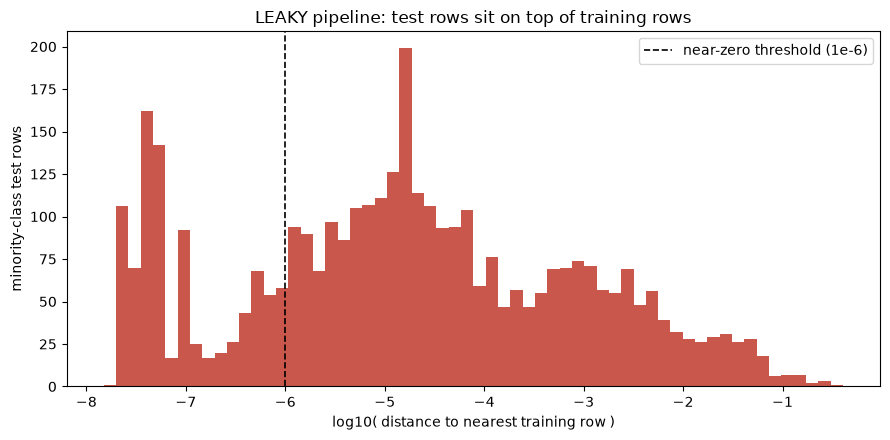

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
finite = leaky_nn.distances[leaky_nn.distances > 0]
ax.hist(np.log10(finite), bins=60, color="#c0392b", alpha=0.85)
ax.axvline(np.log10(1e-6), color="black", ls="--", lw=1.2, label="near-zero threshold (1e-6)")
ax.set_xlabel("log10( distance to nearest training row )")
ax.set_ylabel("minority-class test rows")
ax.set_title("LEAKY pipeline: test rows sit on top of training rows")
ax.legend()
plt.tight_layout()
plt.show()

## Step 7 — Save the leaky result for the T1.2 comparison

In [12]:
summary = results_table([leaky_metrics])
summary["pipeline_order"] = "resample BEFORE split (base paper's order)"
summary["test_fold_synthetic_fraction"] = leaky_contamination.fraction_synthetic
summary["nn_near_zero_fraction"] = leaky_nn.near_zero_fraction
summary.to_csv(REPO_ROOT / "reports" / "t1_1_leaky_result.csv", index=False)
summary.T

,0
model,LEAKY pipeline (SMOTE before split)
positive_class,Attack
accuracy,0.998556
precision,0.997494
recall,0.999624
f1,0.998558
TP,58512
FP,147
TN,58387
FN,22


## Verdict (T1.1 VERIFY block)

The VERIFY condition for T1.1 is: *"Notebook output shows both an implausibly high test accuracy
and a nearest-neighbour distance distribution with a cluster of near-zero distances for
oversampled classes."* Both are shown above, plus a third and stronger piece of evidence — the
direct count of fabricated test rows.

**Objection #1 is now measured, not asserted.** The number this project actually reports as its
baseline is produced in `02_leakage_free_baseline.ipynb`.

### Secondary finding, recorded for later

IoTID20's 163,946 exact duplicate rows are an **independent** leakage vector that the SMOTE
ordering fix does not address. The base paper does not mention deduplication; neither does the
senior's prior work. `clean_iotid20(drop_duplicates=True)` exists so this can be quantified as a
sensitivity check, and it is worth a paragraph in the Review 2 report — it is a defect in the
*dataset's* usage across this literature, not just in one paper.